<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/class_skill_morph_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Dataset/titatnic train.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Dataset Shape:", df.shape)
df.info()
df.describe()

Dataset Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Check current missing values
print("Missing values before injection:\n", df.isnull().sum())

# Inject missing values for teaching
np.random.seed(42)
inject = {
    'Age': 30,
    'Fare': 8,
    'Embarked': 5,
    'Cabin': 40
}

for col, n in inject.items():
    if col in df.columns:
        idx = np.random.choice(df.index, size=n, replace=False)
        df.loc[idx, col] = np.nan

print("\nMissing values after injection:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before injection:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after injection:
Age         202
Fare          8
Cabin       696
Embarked      7
dtype: int64


In [6]:
# Numeric: median, Categorical: mode
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
# Cabin has too many missing → drop for now
df.drop(columns=['Cabin'], inplace=True)

print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 0


In [7]:
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (891, 11)


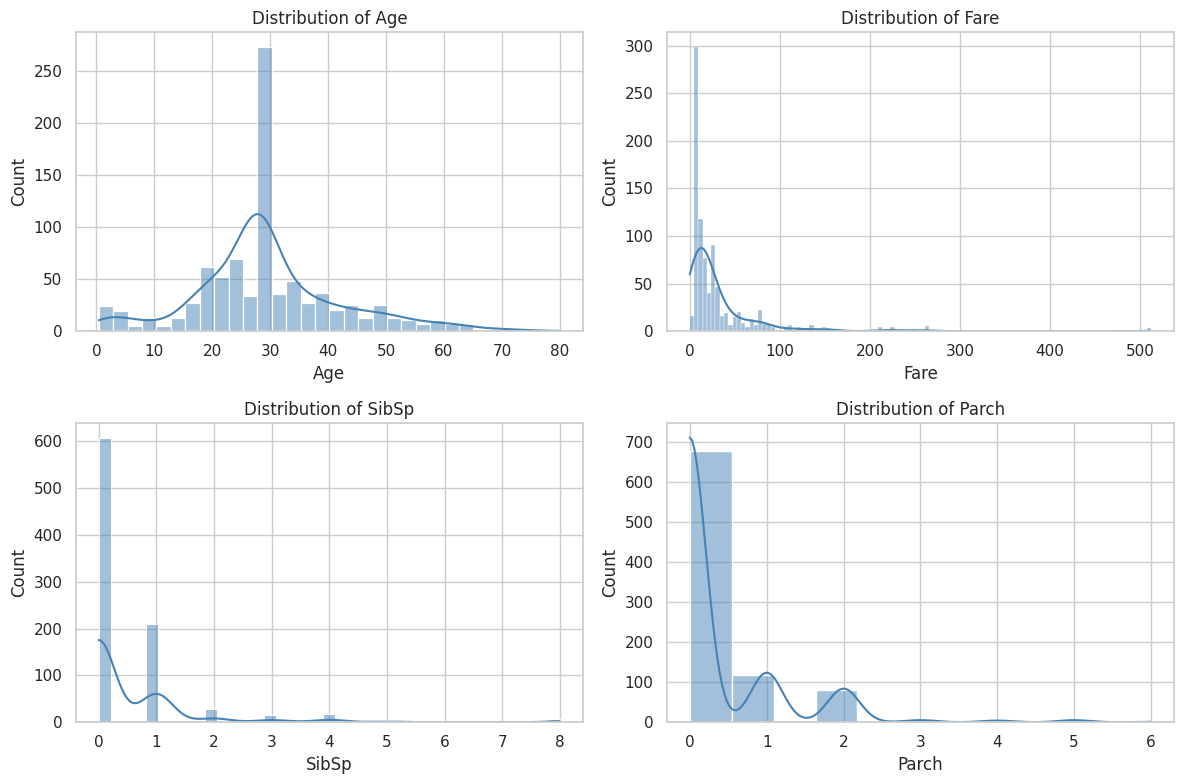

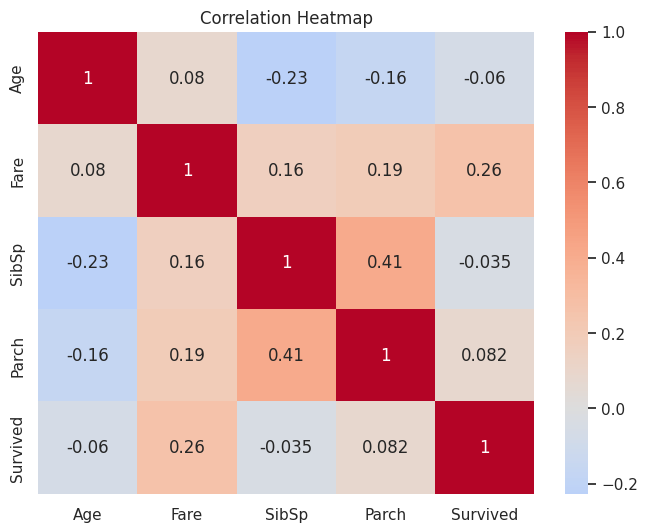

In [13]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols + ['Survived']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [14]:
# Label Encoding for Sex
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

# One-Hot Encoding
df = pd.get_dummies(df, columns=['Embarked', 'Pclass'], drop_first=True)

print("Columns after encoding:", df.columns.tolist())

Columns after encoding: ['PassengerId', 'Survived', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3']


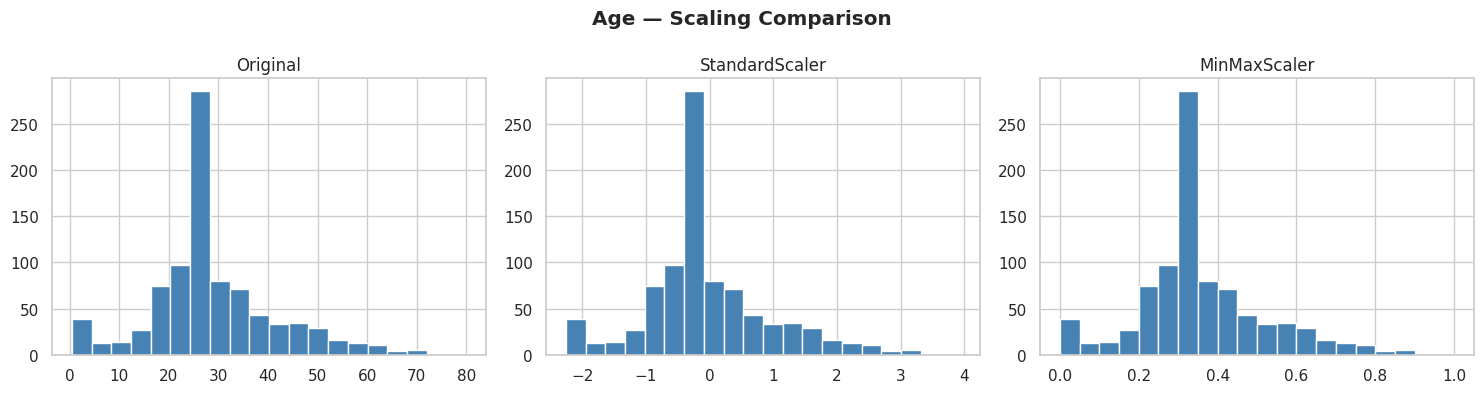

In [15]:
# Compare scaling on Age
scalers = {
    'Original': df['Age'],
    'StandardScaler': pd.Series(StandardScaler().fit_transform(df[['Age']]).flatten()),
    'MinMaxScaler': pd.Series(MinMaxScaler().fit_transform(df[['Age']]).flatten())
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, data) in zip(axes, scalers.items()):
    ax.hist(data, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(name)
plt.suptitle('Age — Scaling Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

X_train: (712, 9)  |  X_test: (179, 9)


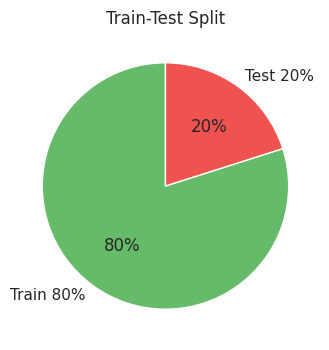

In [16]:
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'])
y = df['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

plt.figure(figsize=(4,4))
plt.pie([len(X_train), len(X_test)], labels=['Train 80%', 'Test 20%'],
        colors=['#66BB6A', '#EF5350'], autopct='%1.0f%%', startangle=90)
plt.title('Train-Test Split')
plt.show()

In [18]:
# Full Pipeline (Clean version for modeling)
data = pd.read_csv('/content/drive/MyDrive/Dataset/titatnic train.csv')

# Drop unnecessary columns
data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# Inject missing (for consistency)
np.random.seed(42)
data.loc[np.random.choice(data.index, 30, replace=False), 'Age'] = np.nan
data.loc[np.random.choice(data.index, 5, replace=False), 'Embarked'] = np.nan

# Imputation
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
data['Fare'].fillna(data['Fare'].median(), inplace=True)

# Encoding
data['Sex'] = LabelEncoder().fit_transform(data['Sex'])
data = pd.get_dummies(data, columns=['Embarked', 'Pclass'], drop_first=True)

# Split
X = data.drop(columns=['Survived'])
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'✅ Full Pipeline Complete → X_train: {X_train.shape}  |  X_test: {X_test.shape}')

✅ Full Pipeline Complete → X_train: (712, 9)  |  X_test: (179, 9)
